In [1]:
#importing required Libraries
import pandas as pd #importing pandas
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind

# Data Preparation
# Questions 2




#   Load Dataset

In [2]:
df = pd.read_csv("ids.csv")
df

,Unnamed: 0,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,0,53,62171,2,2,78,164,39,39,39.00,...,32,0.00000,0.00000,0,0,0.0,0.000000,0,0,BENIGN
1,1,2710,48,2,0,4,0,2,2,2.00,...,24,0.00000,0.00000,0,0,0.0,0.000000,0,0,Infiltration
2,2,443,4792909,5,1,135,46,46,6,27.00,...,20,0.00000,0.00000,0,0,0.0,0.000000,0,0,BENIGN
3,3,80,115596470,75,82,342,118155,342,0,4.56,...,32,22092.63636,22835.59127,90944,14999,10000000.0,2701.650839,10000000,9997164,BENIGN
4,4,2910,14,2,2,4,12,2,2,2.00,...,24,0.00000,0.00000,0,0,0.0,0.000000,0,0,BENIGN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
488110,488110,53,238,2,2,86,228,43,43,43.00,...,32,0.00000,0.00000,0,0,0.0,0.000000,0,0,BENIGN
488111,488111,8899,3,2,0,4,0,2,2,2.00,...,24,0.00000,0.00000,0,0,0.0,0.000000,0,0,Infiltration
488112,488112,53,250,2,2,82,206,41,41,41.00,...,20,0.00000,0.00000,0,0,0.0,0.000000,0,0,BENIGN
488113,488113,53,70581019,2,2,117,231,66,51,58.50,...,32,41306.00000,0.00000,41306,41306,70300000.0,0.000000,70300000,70300000,BENIGN


In [3]:
df= pd.read_csv("ids.csv",index_col=0)
df

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,53,62171,2,2,78,164,39,39,39.00,0.000000,...,32,0.00000,0.00000,0,0,0.0,0.000000,0,0,BENIGN
1,2710,48,2,0,4,0,2,2,2.00,0.000000,...,24,0.00000,0.00000,0,0,0.0,0.000000,0,0,Infiltration
2,443,4792909,5,1,135,46,46,6,27.00,20.124612,...,20,0.00000,0.00000,0,0,0.0,0.000000,0,0,BENIGN
3,80,115596470,75,82,342,118155,342,0,4.56,39.490758,...,32,22092.63636,22835.59127,90944,14999,10000000.0,2701.650839,10000000,9997164,BENIGN
4,2910,14,2,2,4,12,2,2,2.00,0.000000,...,24,0.00000,0.00000,0,0,0.0,0.000000,0,0,BENIGN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
488110,53,238,2,2,86,228,43,43,43.00,0.000000,...,32,0.00000,0.00000,0,0,0.0,0.000000,0,0,BENIGN
488111,8899,3,2,0,4,0,2,2,2.00,0.000000,...,24,0.00000,0.00000,0,0,0.0,0.000000,0,0,Infiltration
488112,53,250,2,2,82,206,41,41,41.00,0.000000,...,20,0.00000,0.00000,0,0,0.0,0.000000,0,0,BENIGN
488113,53,70581019,2,2,117,231,66,51,58.50,10.606602,...,32,41306.00000,0.00000,41306,41306,70300000.0,0.000000,70300000,70300000,BENIGN


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 488115 entries, 0 to 488114
Data columns (total 79 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Destination Port             488115 non-null  int64  
 1   Flow Duration                488115 non-null  int64  
 2   Total Fwd Packets            488115 non-null  int64  
 3   Total Backward Packets       488115 non-null  int64  
 4   Total Length of Fwd Packets  488115 non-null  int64  
 5   Total Length of Bwd Packets  488115 non-null  int64  
 6   Fwd Packet Length Max        488115 non-null  int64  
 7   Fwd Packet Length Min        488115 non-null  int64  
 8   Fwd Packet Length Mean       488115 non-null  float64
 9   Fwd Packet Length Std        488115 non-null  float64
 10  Bwd Packet Length Max        488115 non-null  int64  
 11  Bwd Packet Length Min        488115 non-null  int64  
 12  Bwd Packet Length Mean       488115 non-null  float64
 13  Bwd 

In [5]:
df.describe()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min
count,488115.000000,4.881150e+05,488115.000000,488115.000000,4.881150e+05,4.881150e+05,488115.000000,488115.000000,488115.000000,488115.000000,...,488115.000000,488115.000000,4.881150e+05,4.881150e+05,4.881150e+05,4.881150e+05,4.881150e+05,4.881150e+05,4.881150e+05,4.881150e+05
mean,8216.354384,8.942263e+06,6.206931,6.185579,5.581399e+02,6.222017e+03,140.936187,17.142253,41.737297,40.785650,...,3.436965,25.697270,6.169126e+04,4.144031e+04,1.325706e+05,3.851845e+04,2.606171e+06,1.184684e+05,2.695488e+06,2.483101e+06
std,17541.650108,2.748091e+07,69.852691,99.359121,2.738195e+04,1.788109e+05,438.404840,31.486744,119.415855,138.185083,...,50.611058,5.851988,5.330001e+05,3.753807e+05,9.292890e+05,4.588439e+05,1.067120e+07,1.614595e+06,1.096955e+07,1.050593e+07
min,0.000000,-2.000000e+00,1.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,53.000000,5.900000e+01,2.000000,1.000000,4.000000e+00,0.000000e+00,2.000000,0.000000,2.000000,0.000000,...,1.000000,20.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,443.000000,3.100000e+02,2.000000,2.000000,4.900000e+01,7.200000e+01,32.000000,2.000000,29.000000,0.000000,...,1.000000,24.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,3221.000000,1.002090e+05,3.000000,2.000000,9.500000e+01,2.460000e+02,51.000000,35.000000,46.000000,0.000000,...,1.000000,32.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
max,65533.000000,1.199999e+08,22673.000000,44553.000000,1.290000e+07,6.360000e+07,23360.000000,2065.000000,4317.097561,4467.113460,...,9130.000000,60.000000,6.520000e+07,3.810000e+07,7.910000e+07,6.520000e+07,1.200000e+08,7.530000e+07,1.200000e+08,1.200000e+08


# Display Last 50 Records

In [6]:
df.tail(50) #shows last values

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
488065,53,70591,2,2,66,194,33,33,33.000000,0.000000,...,32,0.00000,0.00000,0,0,0.000000e+00,0.00000,0,0,Infiltration
488066,443,5572560,8,6,386,5205,205,0,48.250000,75.952523,...,20,0.00000,0.00000,0,0,0.000000e+00,0.00000,0,0,BENIGN
488067,3013,49,2,0,4,0,2,2,2.000000,0.000000,...,24,0.00000,0.00000,0,0,0.000000e+00,0.00000,0,0,BENIGN
488068,53,122130,2,2,80,272,40,40,40.000000,0.000000,...,20,0.00000,0.00000,0,0,0.000000e+00,0.00000,0,0,BENIGN
488069,53,98106274,2,2,114,211,58,56,57.000000,1.414214,...,20,30943.00000,0.00000,30943,30943,9.800000e+07,0.00000,98000000,98000000,Infiltration
488070,53,506,1,1,53,113,53,53,53.000000,0.000000,...,32,0.00000,0.00000,0,0,0.000000e+00,0.00000,0,0,BENIGN
488071,53,3957631,2,2,120,260,79,41,60.000000,26.870058,...,20,0.00000,0.00000,0,0,0.000000e+00,0.00000,0,0,BENIGN
488072,9102,2,2,0,4,0,2,2,2.000000,0.000000,...,24,0.00000,0.00000,0,0,0.000000e+00,0.00000,0,0,BENIGN
488073,2135,111,2,2,4,12,2,2,2.000000,0.000000,...,24,0.00000,0.00000,0,0,0.000000e+00,0.00000,0,0,BENIGN
488074,1048,49,2,0,4,0,2,2,2.000000,0.000000,...,24,0.00000,0.00000,0,0,0.000000e+00,0.00000,0,0,Infiltration


#  Create New DataFrame with Required Columns

In [7]:
columns = [
    'Destination Port',
    'Flow Duration',
    'Total Fwd Packets',
    'Total Backward Packets',
    'Total Length of Fwd Packets',
    'Total Length of Bwd Packets',
    'Fwd Packet Length Mean',
    'Bwd Packet Length Mean',
    'Flow Bytes/s',
    'Flow Packets/s',
    'Packet Length Mean',
    'Packet Length Std',
    'Average Packet Size',
    'Active Mean',
    'Idle Mean',
    'Label'
]

df_data=df[columns]
df_data

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Mean,Bwd Packet Length Mean,Flow Bytes/s,Flow Packets/s,Packet Length Mean,Packet Length Std,Average Packet Size,Active Mean,Idle Mean,Label
0,53,62171,2,2,78,164,39.00,82.000000,3.892490e+03,64.338679,56.200000,23.552070,70.250000,0.00000,0.0,BENIGN
1,2710,48,2,0,4,0,2.00,0.000000,8.333333e+04,41666.666670,2.000000,0.000000,3.000000,0.00000,0.0,Infiltration
2,443,4792909,5,1,135,46,27.00,46.000000,3.776412e+01,1.251849,32.428571,18.866700,37.833333,0.00000,0.0,BENIGN
3,80,115596470,75,82,342,118155,4.56,1440.914634,1.025092e+03,1.358173,749.981013,946.124811,754.757962,22092.63636,10000000.0,BENIGN
4,2910,14,2,2,4,12,2.00,6.000000,1.142857e+06,285714.285700,3.600000,2.190890,4.500000,0.00000,0.0,BENIGN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
488110,53,238,2,2,86,228,43.00,114.000000,1.319328e+06,16806.722690,71.400000,38.888302,89.250000,0.00000,0.0,BENIGN
488111,8899,3,2,0,4,0,2.00,0.000000,1.333333e+06,666666.666700,2.000000,0.000000,3.000000,0.00000,0.0,Infiltration
488112,53,250,2,2,82,206,41.00,103.000000,1.152000e+06,16000.000000,65.800000,33.958799,82.250000,0.00000,0.0,BENIGN
488113,53,70581019,2,2,117,231,58.50,115.500000,4.930504e+00,0.056672,82.800000,30.817203,103.500000,41306.00000,70300000.0,BENIGN


#  Check and Remove NaN Values

In [8]:
df_data.isna().sum() # isna() checks which values are missing in the dataset 

Destination Port                0
Flow Duration                   0
Total Fwd Packets               0
Total Backward Packets          0
Total Length of Fwd Packets     0
Total Length of Bwd Packets     0
Fwd Packet Length Mean          0
Bwd Packet Length Mean          0
Flow Bytes/s                   36
Flow Packets/s                  0
Packet Length Mean              0
Packet Length Std               0
Average Packet Size             0
Active Mean                     0
Idle Mean                       0
Label                           0
dtype: int64

In [9]:
df_data = df_data.dropna() # dropna() removes rows with missing values

In [10]:
df_data.isna().sum()

Destination Port               0
Flow Duration                  0
Total Fwd Packets              0
Total Backward Packets         0
Total Length of Fwd Packets    0
Total Length of Bwd Packets    0
Fwd Packet Length Mean         0
Bwd Packet Length Mean         0
Flow Bytes/s                   0
Flow Packets/s                 0
Packet Length Mean             0
Packet Length Std              0
Average Packet Size            0
Active Mean                    0
Idle Mean                      0
Label                          0
dtype: int64

# Check for Duplicate Records

In [11]:
df_data.duplicated().sum()# Count duplicate rows

np.int64(139389)

#  Display Total Columns and Column Names

In [12]:
len(df_data.columns)

16

In [13]:
df_data.columns

Index(['Destination Port', 'Flow Duration', 'Total Fwd Packets',
       'Total Backward Packets', 'Total Length of Fwd Packets',
       'Total Length of Bwd Packets', 'Fwd Packet Length Mean',
       'Bwd Packet Length Mean', 'Flow Bytes/s', 'Flow Packets/s',
       'Packet Length Mean', 'Packet Length Std', 'Average Packet Size',
       'Active Mean', 'Idle Mean', 'Label'],
      dtype='object')

# Rename Label Values

In [14]:
df_data['Label'].value_counts()

Label
BENIGN          288548
Infiltration    199531
Name: count, dtype: int64

In [15]:
df_data.columns

Index(['Destination Port', 'Flow Duration', 'Total Fwd Packets',
       'Total Backward Packets', 'Total Length of Fwd Packets',
       'Total Length of Bwd Packets', 'Fwd Packet Length Mean',
       'Bwd Packet Length Mean', 'Flow Bytes/s', 'Flow Packets/s',
       'Packet Length Mean', 'Packet Length Std', 'Average Packet Size',
       'Active Mean', 'Idle Mean', 'Label'],
      dtype='object')

In [16]:
df_data['Label'] = df_data['Label'].replace({
    'BENIGN': 'Normal Traffic',
    'Infiltration': 'Attack'
})
df_data # Showing updated dataframe

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_2744\3485953891.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_data['Label'] = df_data['Label'].replace({


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Mean,Bwd Packet Length Mean,Flow Bytes/s,Flow Packets/s,Packet Length Mean,Packet Length Std,Average Packet Size,Active Mean,Idle Mean,Label
0,53,62171,2,2,78,164,39.00,82.000000,3.892490e+03,64.338679,56.200000,23.552070,70.250000,0.00000,0.0,Normal Traffic
1,2710,48,2,0,4,0,2.00,0.000000,8.333333e+04,41666.666670,2.000000,0.000000,3.000000,0.00000,0.0,Attack
2,443,4792909,5,1,135,46,27.00,46.000000,3.776412e+01,1.251849,32.428571,18.866700,37.833333,0.00000,0.0,Normal Traffic
3,80,115596470,75,82,342,118155,4.56,1440.914634,1.025092e+03,1.358173,749.981013,946.124811,754.757962,22092.63636,10000000.0,Normal Traffic
4,2910,14,2,2,4,12,2.00,6.000000,1.142857e+06,285714.285700,3.600000,2.190890,4.500000,0.00000,0.0,Normal Traffic
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
488110,53,238,2,2,86,228,43.00,114.000000,1.319328e+06,16806.722690,71.400000,38.888302,89.250000,0.00000,0.0,Normal Traffic
488111,8899,3,2,0,4,0,2.00,0.000000,1.333333e+06,666666.666700,2.000000,0.000000,3.000000,0.00000,0.0,Attack
488112,53,250,2,2,82,206,41.00,103.000000,1.152000e+06,16000.000000,65.800000,33.958799,82.250000,0.00000,0.0,Normal Traffic
488113,53,70581019,2,2,117,231,58.50,115.500000,4.930504e+00,0.056672,82.800000,30.817203,103.500000,41306.00000,70300000.0,Normal Traffic


In [17]:
df_data['Label'].value_counts()

Label
Normal Traffic    288548
Attack            199531
Name: count, dtype: int64

# Milestone 2

# 3 Data Analysis
		


#  Summary Statistics of Selected Variables

In [18]:
# Select two numeric columns from dataset
col1 = "Flow Duration"
col2 = "Total Fwd Packets"

# Create summary table
summary_stats = pd.DataFrame({
    "Sum": [df_data[col1].sum(), df_data[col2].sum()],
    "Mean": [df_data[col1].mean(), df_data[col2].mean()],
    "Std Dev": [df_data[col1].std(), df_data[col2].std()],
    "Skewness": [df_data[col1].skew(), df_data[col2].skew()],
    "Kurtosis": [df_data[col1].kurt(), df_data[col2].kurt()]
}, index=[col1, col2])

summary_stats


,Sum,Mean,Std Dev,Skewness,Kurtosis
Flow Duration,4364852868645,8.942923e+06,2.748182e+07,3.250874,9.246791
Total Fwd Packets,3029633,6.207259e+00,6.985526e+01,137.038109,30406.102822


# Correlation Analysis

In [19]:
# Select only numeric columns
df_data1 = df_data.select_dtypes(include='number')
df_data1.corr()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Mean,Bwd Packet Length Mean,Flow Bytes/s,Flow Packets/s,Packet Length Mean,Packet Length Std,Average Packet Size,Active Mean,Idle Mean
Destination Port,1.000000,-0.145250,-0.025711,-0.024028,0.004815,-0.015581,0.005199,-0.217264,0.063783,0.214177,-0.118523,-0.156795,-0.127719,-0.051505,-0.109348
Flow Duration,-0.145250,1.000000,0.124344,0.100836,0.032044,0.063465,0.114950,0.351037,-0.018884,-0.113359,0.324827,0.465984,0.303080,0.204673,0.653138
Total Fwd Packets,-0.025711,0.124344,1.000000,0.949848,0.333574,0.920007,0.035838,0.210119,-0.002078,-0.020480,0.200438,0.174919,0.190185,0.137132,0.074589
Total Backward Packets,-0.024028,0.100836,0.949848,1.000000,0.146728,0.961480,0.015679,0.200844,-0.002868,-0.020564,0.186629,0.156695,0.177268,0.101969,0.066117
Total Length of Fwd Packets,0.004815,0.032044,0.333574,0.146728,1.000000,0.013944,0.127556,0.016333,0.001838,-0.006509,0.080155,0.054492,0.077949,0.058811,0.013443
Total Length of Bwd Packets,-0.015581,0.063465,0.920007,0.961480,0.013944,1.000000,-0.001047,0.194512,-0.001385,-0.012061,0.176026,0.138066,0.167419,0.078208,0.048474
Fwd Packet Length Mean,0.005199,0.114950,0.035838,0.015679,0.127556,-0.001047,1.000000,0.123866,0.154969,-0.078665,0.612858,0.462664,0.628276,0.068762,0.074170
Bwd Packet Length Mean,-0.217264,0.351037,0.210119,0.200844,0.016333,0.194512,0.123866,1.000000,-0.024280,-0.166846,0.824952,0.876817,0.809420,0.187768,0.236769
Flow Bytes/s,0.063783,-0.018884,-0.002078,-0.002868,0.001838,-0.001385,0.154969,-0.024280,1.000000,0.200319,0.127875,0.069086,0.188463,-0.006707,-0.014174
Flow Packets/s,0.214177,-0.113359,-0.020480,-0.020564,-0.006509,-0.012061,-0.078665,-0.166846,0.200319,1.000000,-0.134655,-0.145674,-0.135588,-0.040319,-0.085080


# Top 5 Correlation Analysis 


In [22]:
# Select only numerical columns from the dataframe for correlation analysis
df_data1 = df_data.select_dtypes(include='number')

corr_matrixs = df_data1.corr()  # Calculate correlation between all features

corr_pair = corr_matrixs.unstack() # Convert matrix to feature pairs

corr_pair = corr_pair[corr_pair != 1] # Remove same variable correlation(value = 1)

corr_pair = corr_pair.drop_duplicates() # Remove duplicate pairs

topfive = corr_pair.reindex(corr_pair.abs().sort_values(ascending=False).index) # Sort by highest correlation

print("Top 5 Correlated Feature Pairs:\n")# Print top 5 correlated pairs
print(topfive.head(5))

Top 5 Correlated Feature Pairs:

Packet Length Mean      Average Packet Size            0.995068
Total Backward Packets  Total Length of Bwd Packets    0.961480
Total Fwd Packets       Total Backward Packets         0.949848
                        Total Length of Bwd Packets    0.920007
Packet Length Mean      Packet Length Std              0.887792
dtype: float64


<Axes: >

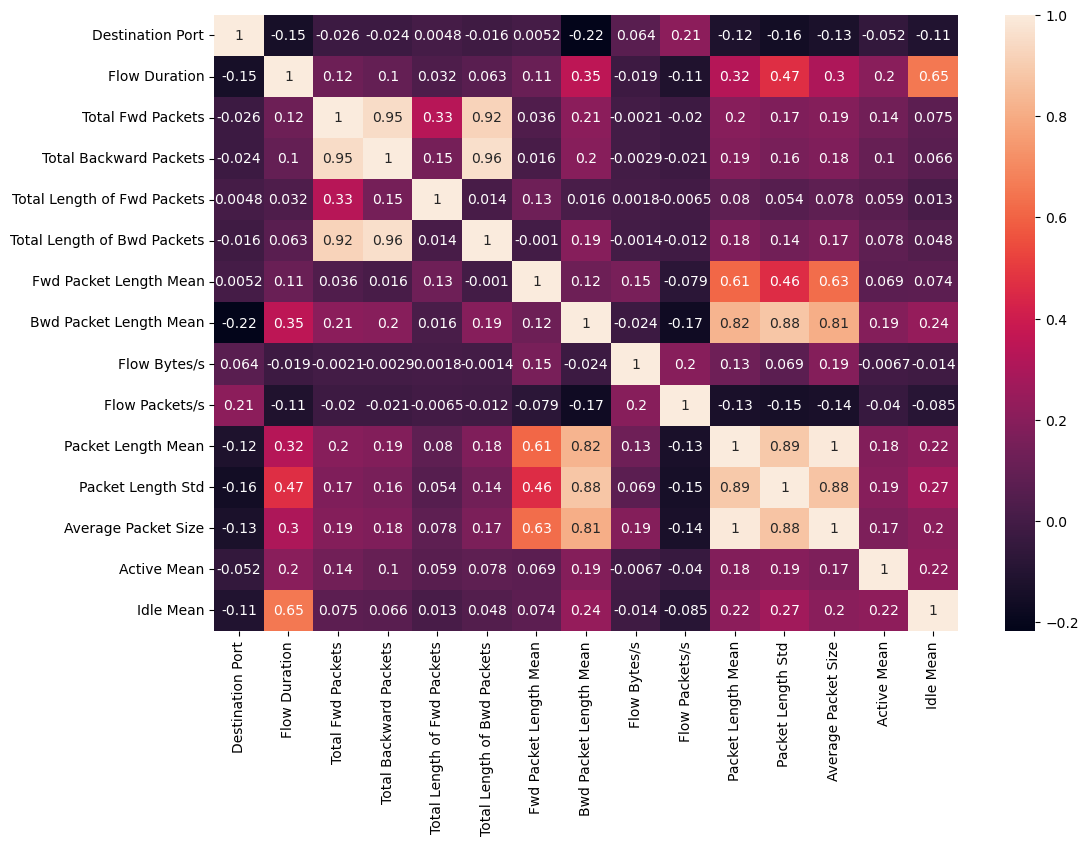

In [23]:
# Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(df_data1.corr(), annot=True)

# Question 4 DATA EXPLORATION

# Bar Chart of Label Distribution

Text(0, 0.5, 'Frequency')

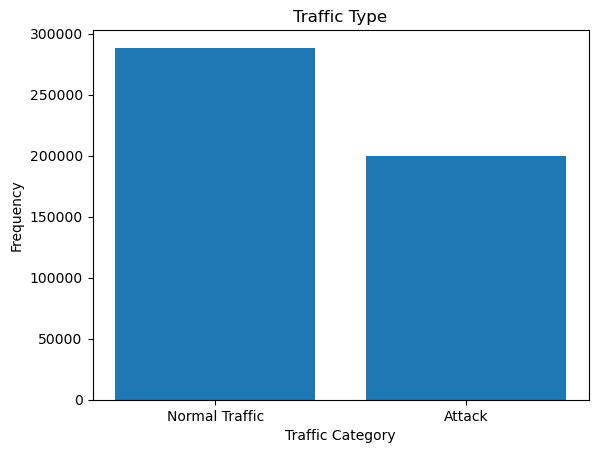

In [24]:

# Count values
label_count = df_data['Label'].value_counts()

# Plot bar chart

plt.bar(label_count.index, label_count.values)

plt.title("Traffic Type")
plt.xlabel("Traffic Category")
plt.ylabel("Frequency")

#  Normal Traffic and Attack Piechart(Flow Duration)

Text(0.5, 1.0, 'Flow Duration')

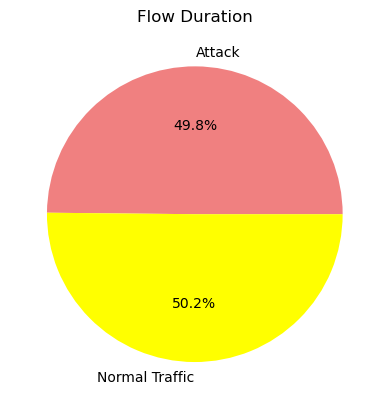

In [25]:

avg_data = df_data.groupby('Label').mean()

plt.pie(avg_data['Flow Duration'], labels=avg_data.index, autopct='%1.1f%%', colors=['lightcoral', 'yellow'])
plt.title("Flow Duration")


#  Normal Traffic and Attack Piechart(Packet Length Mean)

Text(0.5, 1.0, 'Packet Length Mean')

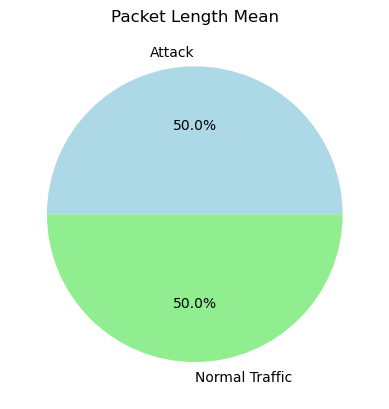

In [26]:
plt.pie(avg_data['Packet Length Mean'], labels=avg_data.index, autopct='%1.1f%%', colors=['lightblue', 'lightgreen'])
plt.title("Packet Length Mean")


#  Boxplot Analysis


Text(0, 0.5, 'Fwd Packet Length Mean')

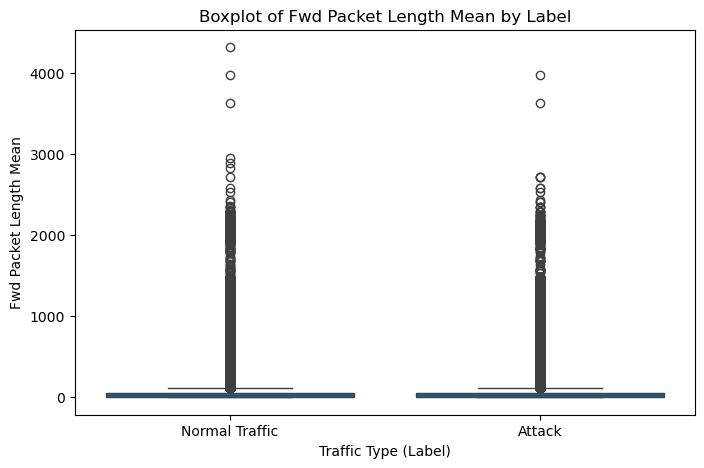

In [28]:
plt.figure(figsize=(8,5))

sns.boxplot( x='Label',y='Fwd Packet Length Mean',data=df_data)

plt.title("Boxplot of Fwd Packet Length Mean by Label")
plt.xlabel("Traffic Type (Label)")
plt.ylabel("Fwd Packet Length Mean")

# Removing all outlier points

Text(0, 0.5, 'Fwd Packet Length Mean')

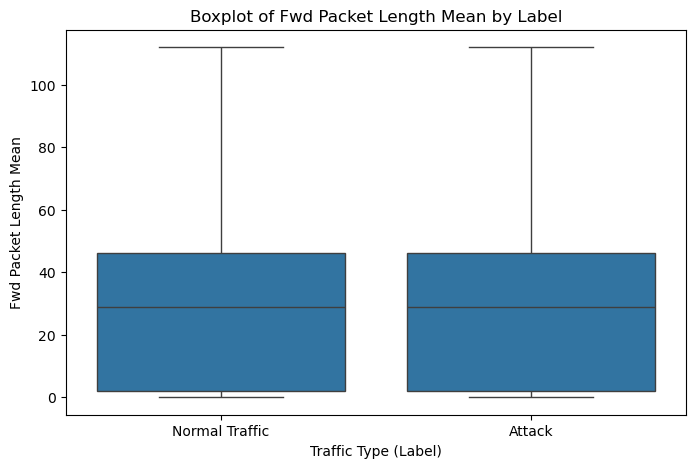

In [37]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='Label',y='Fwd Packet Length Mean',data=df_data,showfliers=False)  # Cleanly removes all outlier points
plt.title("Boxplot of Fwd Packet Length Mean by Label")
plt.xlabel("Traffic Type (Label)")
plt.ylabel("Fwd Packet Length Mean")

# Hypothesis Testing

In [23]:
# Extract 'Flow Duration' values for Normal Traffic and Attack classes into separate Series objects for statistical comparison.
normalTraffic = df_data[df_data['Label'] == 'Normal Traffic']["Flow Duration"]
attack = df_data[df_data['Label'] == 'Attack']["Flow Duration"]

# If p < 0.05, significant difference exists; else, no significant difference.
t_stat, p_value = ttest_ind(normalTraffic, attack, equal_var=False)

print("P-value:", p_value)

# If p < 0.05, means Pass; otherwise, Fail.
#checking the difference
if p_value < 0.05:
    print("Pass")
else:
    print("Fail")

P-value: 0.47360098679301743
Fail
